# Quantitative fundamental analysis — `qufin.fundamentals`

Where the rest of `qufin` reads *prices*, this package reads the **financial
statements** behind them. It turns the income statement, balance sheet, and
cash-flow statement into a single flat `FundamentalSnapshot`, then layers the
classic toolkit of fundamental analysis on top:

* **Ratios** — profitability, liquidity, leverage, efficiency, per-share.
* **Multiples** — P/E, P/B, EV/EBITDA, FCF yield, PEG.
* **Intrinsic valuation** — two-stage DCF, the dividend discount model, and the
  residual-income (Edwards-Bell-Ohlson) model.
* **Composite scores** — Piotroski **F-Score** (quality), Altman **Z-Score**
  (bankruptcy risk), Beneish **M-Score** (earnings-manipulation risk).
* **Growth & DuPont** — CAGR, sustainable growth, and the 3- and 5-factor
  decomposition of ROE.
* **Cross-sectional screening** — z-score / rank a whole universe and build a
  weighted-composite factor model.

**Design.** Every analytic takes a `FundamentalSnapshot` (or a polars universe
frame) and never touches the network, so results are deterministic and
testable. Missing line items propagate as `NaN` rather than raising — a partial
statement still yields a partial answer.

**Sections**

0. Data — real statements via yfinance, with a synthetic fallback
1. Ratios and the DuPont decomposition of ROE
2. Valuation multiples
3. Intrinsic valuation: DCF, DDM, residual income
4. Quality and distress scores
5. Cross-sectional screening of a universe


In [1]:
from __future__ import annotations

import math

import matplotlib.pyplot as plt
import polars as pl

from qufin.fundamentals import (
    FundamentalSnapshot,
    compute_ratios, dupont_5factor, sustainable_growth_rate,
    enterprise_value, pe_ratio, pb_ratio, ev_to_ebitda, fcf_yield,
    two_stage_dcf, gordon_growth_ddm, residual_income_value,
    piotroski_f_score, altman_z_score, altman_z_double_prime, beneish_m_score,
    rank_universe,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 0. Data

We try to pull two consecutive fiscal years for a large-cap issuer via
`load_financial_statements`. The current and prior snapshots are both needed by
the *change* models (Piotroski, Beneish). Offline, the loader falls back to a
fully-populated synthetic pair so every cell below still runs.


In [2]:
TICKER = 'MSFT'

def _synthetic_pair():
    prev = FundamentalSnapshot(
        revenue=200_000, cogs=70_000, gross_profit=130_000, operating_income=85_000,
        ebit=85_000, ebitda=100_000, interest_expense=2_000, pretax_income=83_000,
        tax_expense=12_000, net_income=71_000, sga_expense=30_000, depreciation=15_000,
        total_assets=400_000, current_assets=160_000, cash=80_000, inventory=5_000,
        receivables=40_000, total_liabilities=190_000, current_liabilities=80_000,
        total_debt=60_000, long_term_debt=50_000, ppe_net=90_000, total_equity=210_000,
        retained_earnings=150_000, operating_cash_flow=90_000, capex=-25_000,
        free_cash_flow=65_000, dividends_paid=-18_000, shares_outstanding=7_500,
        ticker='SYNTH', period='FY-1',
    )
    curr = FundamentalSnapshot(
        revenue=230_000, cogs=78_000, gross_profit=152_000, operating_income=100_000,
        ebit=100_000, ebitda=118_000, interest_expense=1_900, pretax_income=98_100,
        tax_expense=14_000, net_income=84_100, sga_expense=33_000, depreciation=17_000,
        total_assets=440_000, current_assets=180_000, cash=95_000, inventory=5_500,
        receivables=44_000, total_liabilities=195_000, current_liabilities=82_000,
        total_debt=55_000, long_term_debt=45_000, ppe_net=100_000, total_equity=245_000,
        retained_earnings=200_000, operating_cash_flow=105_000, capex=-28_000,
        free_cash_flow=77_000, dividends_paid=-20_000, price=420.0,
        shares_outstanding=7_400, market_cap=420.0 * 7_400, ticker='SYNTH', period='FY',
    )
    return 'SYNTH', curr, prev


def load_pair(ticker=TICKER):
    try:
        import yfinance as yf

        from qufin.fundamentals import load_financial_statements
        stmts = load_financial_statements(ticker)
        if len(stmts.periods()) >= 2:
            fast = yf.Ticker(ticker).fast_info
            curr = stmts.snapshot(
                -1,
                price=float(fast['last_price']),
                shares_outstanding=float(fast['shares']),
                market_cap=float(fast['market_cap']),
            )
            prev = stmts.snapshot(-2)
            if not math.isnan(curr.revenue) and not math.isnan(curr.total_assets):
                return ticker, curr, prev
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic fundamentals')
    return _synthetic_pair()


name, curr, prev = load_pair()
print(f'issuer={name}  period={curr.period}  currency-units')
print(f'revenue={curr.revenue:,.0f}  net income={curr.net_income:,.0f}  '
      f'equity={curr.total_equity:,.0f}  price={curr.price:,.2f}')

issuer=MSFT  period=2025-06-30  currency-units
revenue=281,724,000,000  net income=101,832,000,000  equity=343,479,000,000  price=411.74


## 1. Ratios and the DuPont decomposition

`compute_ratios(curr, prev)` returns the full `RatioSet`. Passing the prior
snapshot lets balance-based ratios (ROA, ROE, turnover) use the **average**
balance across the two periods, as analysts conventionally do.


In [3]:
rs = compute_ratios(curr, prev)
for k, v in rs.as_dict().items():
    print(f'{k:<30}{v:10.3f}')

gross_margin                       0.688
operating_margin                   0.456
net_margin                         0.361
ebitda_margin                      0.569
return_on_assets                   0.180
return_on_equity                   0.333
return_on_invested_capital         0.281
current_ratio                      1.353
quick_ratio                        1.347
cash_ratio                         0.214
debt_to_equity                     0.176
debt_to_assets                     0.098
net_debt_to_ebitda                 0.189
interest_coverage                 52.835
asset_turnover                     0.498
inventory_turnover                80.431
receivables_turnover               4.443
eps                               13.708
book_value_per_share              46.238
fcf_per_share                      9.640


### Why does this firm earn its ROE?

Two firms with identical ROE can get there very differently. The **5-factor
DuPont** decomposition splits ROE into tax burden x interest burden x operating
margin x asset turnover x equity multiplier, separating operating skill from
financial leverage and the tax/interest drag.


5-factor DuPont ROE = 0.2965
  tax_burden             0.824
  interest_burden        0.981
  operating_margin       0.447
  asset_turnover         0.455
  equity_multiplier      1.802

sustainable growth rate = 22.636% (payout=23.6%)


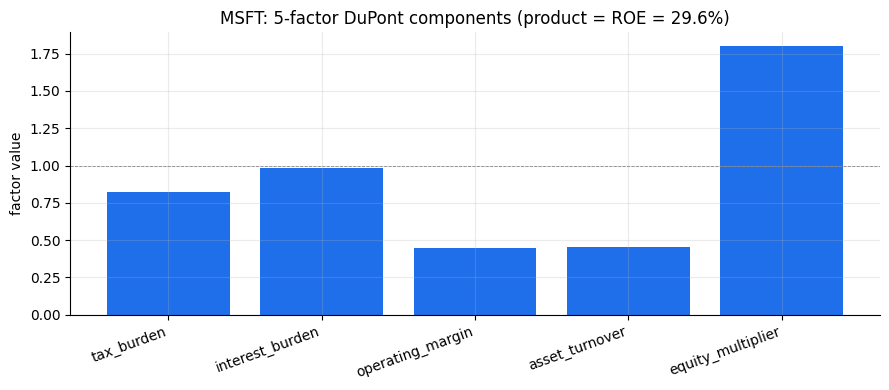

In [4]:
dp = dupont_5factor(curr)
print(f'5-factor DuPont ROE = {dp.roe:.4f}')
for factor, value in dp.factors.items():
    print(f'  {factor:<20}{value:8.3f}')

payout = abs(curr.dividends_paid) / curr.net_income if curr.net_income else float('nan')
print(f'\nsustainable growth rate = {sustainable_growth_rate(dp.roe, payout):.3%} '
      f'(payout={payout:.1%})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(list(dp.factors), list(dp.factors.values()), color='#1f6feb')
ax.axhline(1.0, color='#888', lw=0.6, ls='--')
ax.set_title(f'{name}: 5-factor DuPont components (product = ROE = {dp.roe:.1%})')
ax.set_ylabel('factor value')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 2. Valuation multiples

Multiples need the snapshot's market fields (`price`, `shares_outstanding`,
`market_cap`); the loader fills them from the live quote. Equity multiples use
market cap, enterprise multiples use `enterprise_value = market cap + net debt`.


In [5]:
print(f'enterprise value  {enterprise_value(curr):,.0f}')
print(f'P/E               {pe_ratio(curr):8.2f}')
print(f'P/B               {pb_ratio(curr):8.2f}')
print(f'EV/EBITDA         {ev_to_ebitda(curr):8.2f}')
print(f'FCF yield         {fcf_yield(curr):8.2%}')

enterprise value  3,088,929,632,482
P/E                  30.04
P/B                   8.90
EV/EBITDA            19.29
FCF yield            2.34%


## 3. Intrinsic valuation

Unlike multiples, the intrinsic models take *forward* assumptions you supply.
The **two-stage DCF** grows free cash flow at a high rate for a few years, then
at a perpetual terminal rate; enterprise value is the present value of those
flows, and equity value subtracts net debt.


explicit FCF0      71,611,000,000
enterprise value   1,426,711,691,662
equity value       1,396,365,691,662
value per share    187.98   (price 411.74)


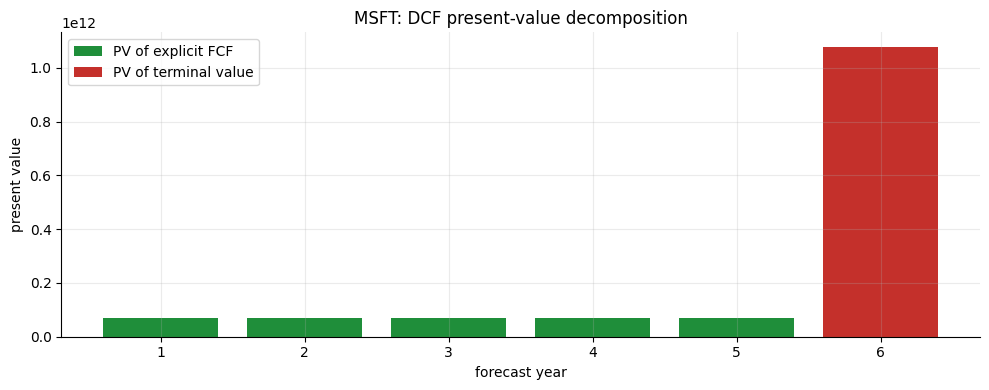

In [6]:
fcf0 = curr.free_cash_flow
if math.isnan(fcf0):
    fcf0 = curr.operating_cash_flow + curr.capex

val = two_stage_dcf(
    fcf0, high_growth=0.08, high_years=5, terminal_growth=0.025,
    discount_rate=0.09, net_debt=curr.net_debt(),
    shares_outstanding=curr.shares_outstanding,
)
print(f'explicit FCF0      {fcf0:,.0f}')
print(f'enterprise value   {val.enterprise_value:,.0f}')
print(f'equity value       {val.equity_value:,.0f}')
print(f'value per share    {val.value_per_share:,.2f}   (price {curr.price:,.2f})')

years = range(1, len(val.pv_cash_flows) + 1)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(list(years), val.pv_cash_flows, color='#1f8e3a', label='PV of explicit FCF')
ax.bar([len(val.pv_cash_flows) + 1], [val.pv_terminal], color='#c4302b',
       label='PV of terminal value')
ax.set_title(f'{name}: DCF present-value decomposition')
ax.set_xlabel('forecast year'); ax.set_ylabel('present value'); ax.legend()
plt.tight_layout(); plt.show()

### Dividend discount and residual income

The **Gordon DDM** values a growing dividend perpetuity; the **residual-income
model** values the firm as book equity plus the present value of returns earned
*above* the cost of equity. With no excess return (ROE = cost of equity) the RI
model collapses to book value — a useful sanity check.


In [7]:
d1 = abs(curr.dividends_paid) / curr.shares_outstanding * 1.05
ddm = gordon_growth_ddm(d1, discount_rate=0.08, growth=0.05)
print(f'Gordon DDM value/share          {ddm:,.2f}  (D1={d1:.2f})')

book0 = curr.total_equity
roe = rs.return_on_equity
ri = residual_income_value(book0, roe=roe, cost_of_equity=0.09,
                           growth=0.04, years=5, terminal_growth=0.025)
print(f'residual-income equity value    {ri:,.0f}  (book {book0:,.0f}, ROE {roe:.1%})')

no_excess = residual_income_value(book0, roe=0.09, cost_of_equity=0.09,
                                  growth=0.04, years=5, terminal_growth=0.025)
print(f'  sanity: ROE == r -> value == book?  {math.isclose(no_excess, book0)}')

Gordon DDM value/share          113.47  (D1=3.40)
residual-income equity value    1,692,463,618,797  (book 343,479,000,000, ROE 33.3%)
  sanity: ROE == r -> value == book?  True


## 4. Quality and distress scores

Three battle-tested composites:

* **Piotroski F (0-9)** — nine yes/no signals of improving fundamentals.
* **Altman Z** — bankruptcy risk; `> 2.99` safe, `< 1.81` distress. Use
  `altman_z_double_prime` for non-manufacturers (it uses *book* equity, so it
  needs no quote).
* **Beneish M** — earnings-manipulation risk; `> -1.78` flags a likely
  manipulator.


In [8]:
f = piotroski_f_score(curr, prev)
print(f'Piotroski F-Score: {f.score}/9')
for signal, passed in f.as_dict().items():
    print(f'  [{"x" if passed else " "}] {signal}')

z = altman_z_score(curr)
zpp = altman_z_double_prime(curr)
print(f'\nAltman Z       {z.score:6.2f}  ->  {z.zone}')
print(f'Altman Z\'\'    {zpp.score:6.2f}  ->  {zpp.zone}')

m = beneish_m_score(curr, prev)
flag = 'LIKELY MANIPULATOR' if m.manipulator else 'no flag'
print(f'\nBeneish M-Score {m.score:6.2f}  ->  {flag}')

Piotroski F-Score: 6/9
  [x] positive_net_income
  [x] positive_operating_cash_flow
  [ ] rising_roa
  [x] cash_flow_exceeds_net_income
  [x] falling_leverage
  [x] rising_current_ratio
  [x] no_new_shares
  [ ] rising_gross_margin
  [ ] rising_asset_turnover

Altman Z         8.42  ->  safe
Altman Z''      4.46  ->  safe

Beneish M-Score  -2.56  ->  no flag


### Beneish in action: a crafted manipulator

Real, healthy firms rarely trip the M-Score, so to *see* it fire we compare a
stable firm against one with the classic red flags — receivables and revenue
ballooning while cash flow lags net income (high accruals).


In [9]:
clean_prev = FundamentalSnapshot(
    revenue=1_000, cogs=600, receivables=100, current_assets=400, ppe_net=500,
    total_assets=1_000, depreciation=50, sga_expense=100, current_liabilities=200,
    long_term_debt=300, net_income=80, operating_cash_flow=80,
)
clean_curr = FundamentalSnapshot(
    revenue=1_100, cogs=660, receivables=110, current_assets=440, ppe_net=550,
    total_assets=1_100, depreciation=55, sga_expense=110, current_liabilities=220,
    long_term_debt=330, net_income=88, operating_cash_flow=88,
)
manip_curr = FundamentalSnapshot(
    revenue=1_500, cogs=1_100, receivables=300, current_assets=500, ppe_net=700,
    total_assets=1_600, depreciation=40, sga_expense=120, current_liabilities=400,
    long_term_debt=600, net_income=200, operating_cash_flow=20,
)
clean = beneish_m_score(clean_curr, clean_prev)
manip = beneish_m_score(manip_curr, clean_prev)
print(f'stable firm   M = {clean.score:6.2f}  manipulator? {clean.manipulator}')
print(f'aggressive    M = {manip.score:6.2f}  manipulator? {manip.manipulator}')
print(f'  drivers: DSRI={manip.dsri:.2f} SGI={manip.sgi:.2f} '
      f'TATA={manip.tata:.2f} GMI={manip.gmi:.2f}')

stable firm   M =  -2.39  manipulator? False
aggressive    M =   0.31  manipulator? True
  drivers: DSRI=2.00 SGI=1.50 TATA=0.11 GMI=1.50


## 5. Cross-sectional screening

`rank_universe` standardises each factor across a universe (one row per
ticker), flips the sign of factors where *lower is better* (P/E, leverage),
weights them, and ranks. Missing factors are treated as neutral rather than
disqualifying. Here we score six names on quality + value.


shape: (6, 6)
┌──────┬────────┬──────┬──────┬────────────────┬───────────┐
│ rank ┆ ticker ┆ roe  ┆ pe   ┆ debt_to_equity ┆ composite │
│ ---  ┆ ---    ┆ ---  ┆ ---  ┆ ---            ┆ ---       │
│ u32  ┆ str    ┆ f64  ┆ f64  ┆ f64            ┆ f64       │
╞══════╪════════╪══════╪══════╪════════════════╪═══════════╡
│ 1    ┆ AAA    ┆ 0.34 ┆ 28.0 ┆ 0.3            ┆ 2.822325  │
│ 2    ┆ EEE    ┆ 0.27 ┆ 24.0 ┆ 0.2            ┆ 2.721499  │
│ 3    ┆ CCC    ┆ 0.12 ┆ 14.0 ┆ 0.45           ┆ 2.048085  │
│ 4    ┆ BBB    ┆ 0.21 ┆ 19.0 ┆ 0.8            ┆ 0.934358  │
│ 5    ┆ DDD    ┆ 0.08 ┆ 33.0 ┆ 1.6            ┆ -3.313578 │
│ 6    ┆ FFF    ┆ 0.05 ┆ 41.0 ┆ 2.1            ┆ -5.212689 │
└──────┴────────┴──────┴──────┴────────────────┴───────────┘


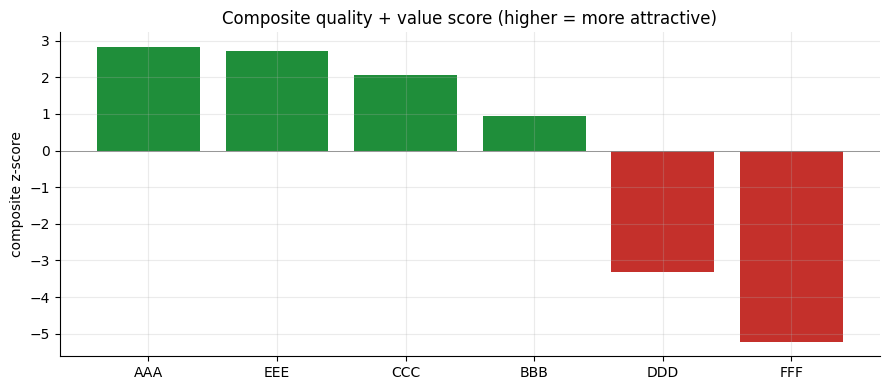

In [10]:
universe = pl.DataFrame({
    'ticker':         ['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF'],
    'roe':            [0.34, 0.21, 0.12, 0.08, 0.27, 0.05],
    'fcf_yield':      [0.045, 0.030, 0.061, 0.018, 0.052, 0.011],
    'net_margin':     [0.31, 0.18, 0.09, 0.06, 0.24, 0.03],
    'debt_to_equity': [0.30, 0.80, 0.45, 1.60, 0.20, 2.10],
    'pe':             [28.0, 19.0, 14.0, 33.0, 24.0, 41.0],
})

ranked = rank_universe(
    universe,
    weights={'roe': 1.0, 'fcf_yield': 1.0, 'net_margin': 0.5,
             'debt_to_equity': 0.5, 'pe': 1.0},
    higher_is_better={'roe': True, 'fcf_yield': True, 'net_margin': True,
                      'debt_to_equity': False, 'pe': False},
)
print(ranked.select('rank', 'ticker', 'roe', 'pe', 'debt_to_equity', 'composite'))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#1f8e3a' if c >= 0 else '#c4302b' for c in ranked['composite']]
ax.bar(ranked['ticker'], ranked['composite'], color=colors)
ax.axhline(0, color='#888', lw=0.6)
ax.set_title('Composite quality + value score (higher = more attractive)')
ax.set_ylabel('composite z-score'); plt.tight_layout(); plt.show()

## What next?

* **Build the universe from real data.** Loop `load_snapshot` over a basket,
  pull each factor with the ratio/multiple helpers, and feed the resulting
  frame straight into `rank_universe`.
* **Combine with price signals.** A fundamental composite makes a natural
  *filter* on top of the technical strategies elsewhere in `qufin` — e.g. only
  trade momentum names in the top quality quintile.
* **Watch the data gaps.** yfinance statement coverage is uneven; the rarer
  Beneish inputs (net PP&E, depreciation, SG&A) are often missing, so an M-Score
  of `NaN` means "insufficient data", not "clean".
* **Quarterly vs annual.** Pass `frequency='quarterly'` to the loader for a
  TTM-style view, but remember the change models then compare adjacent quarters.
